\noindent 
<!-- space at end matters -->
**Parameter setting.** There are two versions of this notebook. The only cell in which they differ is the following, where the parameter indicating the fraction of mutations that are beneficial is assigned a value of either `'1e-3'` or `'1e-6'`.

In [1]:
fraction_of_mutations_that_are_beneficial = '1e-3'
!TZ=America/Chicago date

Sun Nov 25 02:44:07 CST 2018


# Introduction

## Overview of the experiment

[<span style='color:red;'>More here</span>]

## Note on viewing results

We recommend opening different versions of this notebook in different windows, and placing the windows side-by-side. It may be helpful, when comparing graphical outputs, to reduce the scale of display in the windows.

# Calculate equilibrium distributions for various fitness limits

In [2]:
%matplotlib notebook
%run ../../Code/bs.py
%run -i ../../Code/multiprecision_gamma.py
%run -i ../../Code/gamma.py

In [3]:
"""
The initial calculations are done in high-precision floating point. We
convert the results to conventional float64 later, to speed calculations.
"""
def partition_fitness(max_fitness, bin_width=5e-4):
    max_fitness = mp_float(max_fitness)
    min_fitness = mp_float('-0.1')
    return Factors.construct(min_fitness, max_fitness, bin_width)

def equilibrium(factors, log_number_of_loci=0):
    weight = mp_float(fraction_of_mutations_that_are_beneficial)
    mutations = WeightedDoubleGamma(factors, weight=weight)
    mutations.normalize()
    factors.convert(float)
    mutations.convert(float)
    mutation_rate = 1
    mutations.iid_effects(mutation_rate, log_number_of_loci)
    unused = Frequencies(factors)
    pop = Population(unused, mutations, matrix=True)
    return pop.equilibrium()

upper_limits = ['0.05', '0.06', '0.07', '0.08', '0.09', '0.10']
factors = [partition_fitness(limit) for limit in upper_limits]
eq_one_locus = [equilibrium(f, 0) for f in factors]
eq_many_loci = [equilibrium(f, 14) for f in factors]

# Output means and variances of equilibrium distributions

In [4]:
def print_means_and_variances(upper_limits, factors, equilibria):
    label = 'Limit {0}: mean {1:+5.3e} variance {2:5.3e}'
    for limit, f, eq in zip(upper_limits, factors, equilibria):
        m, v = mean_and_variance(f.growth, eq)
        print('    ', label.format(limit, m, v))
    
print('One Locus')
print_means_and_variances(upper_limits, factors, eq_one_locus)
print('Many Loci')
print_means_and_variances(upper_limits, factors, eq_many_loci)

One Locus
     Limit 0.05: mean -6.904e-03 variance 9.135e-05
     Limit 0.06: mean -1.582e-04 variance 9.797e-05
     Limit 0.07: mean +6.607e-03 variance 1.046e-04
     Limit 0.08: mean +1.339e-02 variance 1.113e-04
     Limit 0.09: mean +2.019e-02 variance 1.179e-04
     Limit 0.10: mean +2.700e-02 variance 1.246e-04
Many Loci
     Limit 0.05: mean +2.904e-04 variance 9.841e-05
     Limit 0.06: mean +7.418e-03 variance 1.054e-04
     Limit 0.07: mean +1.456e-02 variance 1.124e-04
     Limit 0.08: mean +2.172e-02 variance 1.194e-04
     Limit 0.09: mean +2.890e-02 variance 1.265e-04
     Limit 0.10: mean +3.609e-02 variance 1.335e-04


# Plot equilibrium distributions

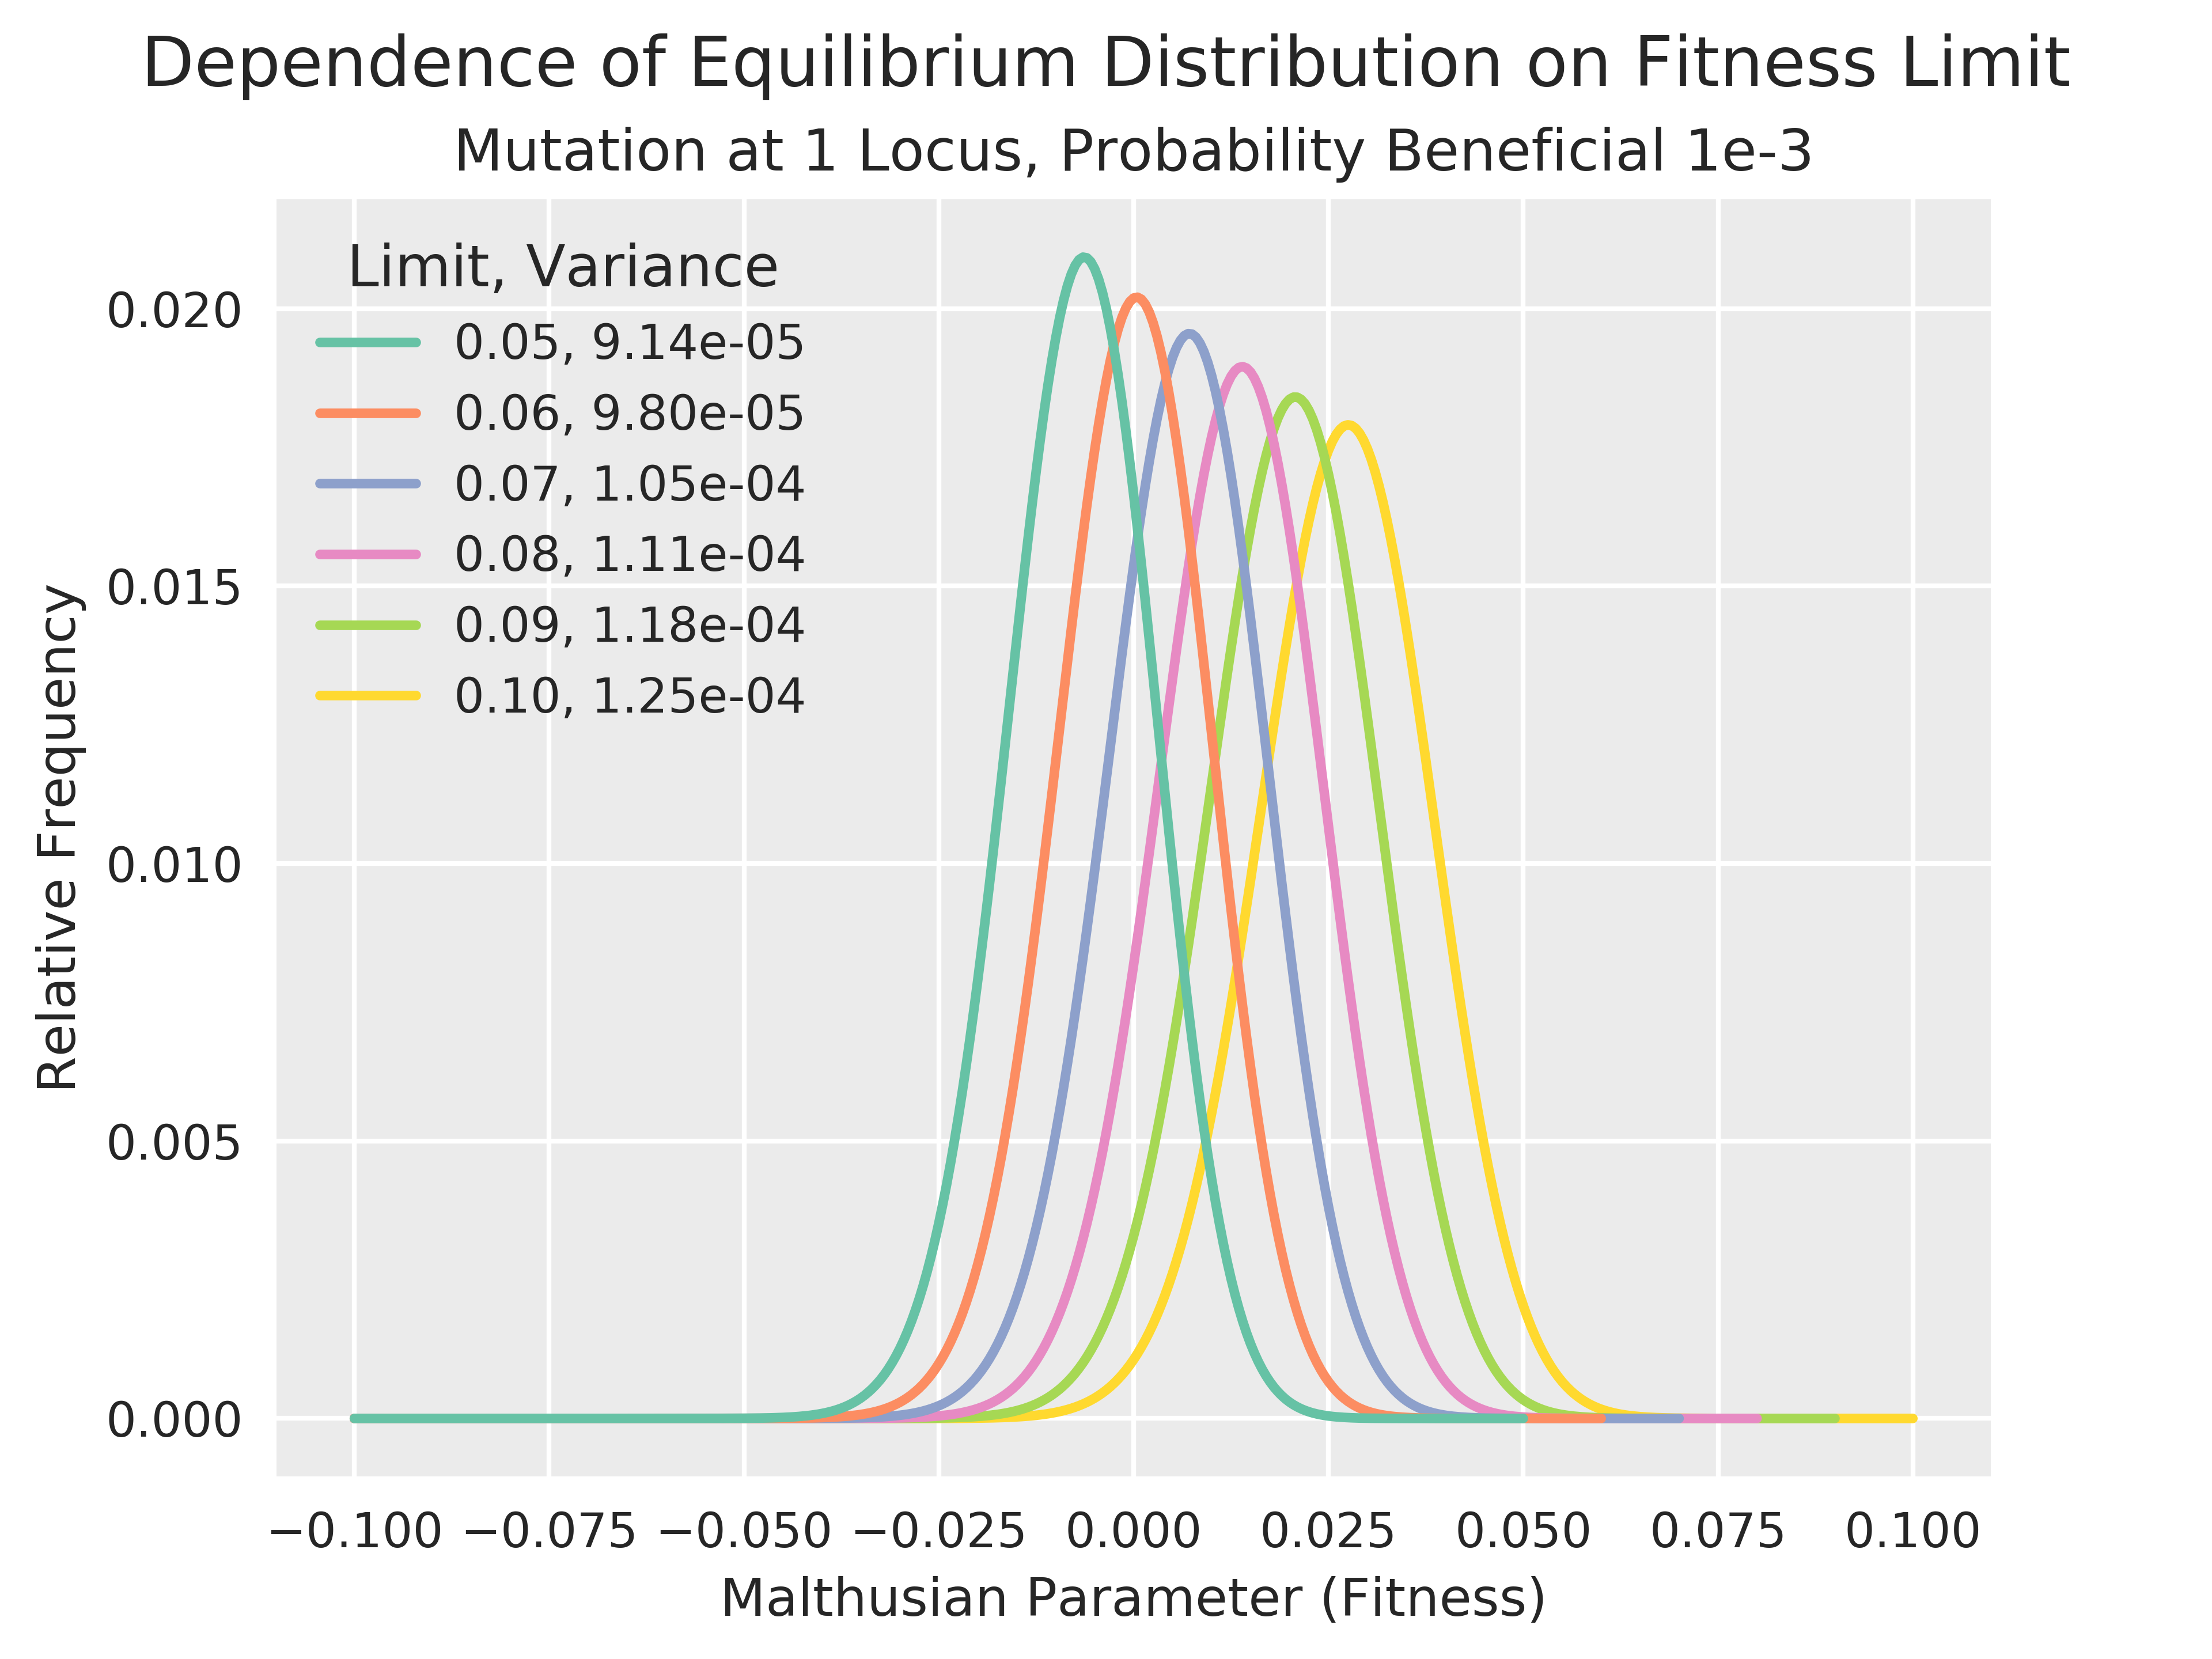

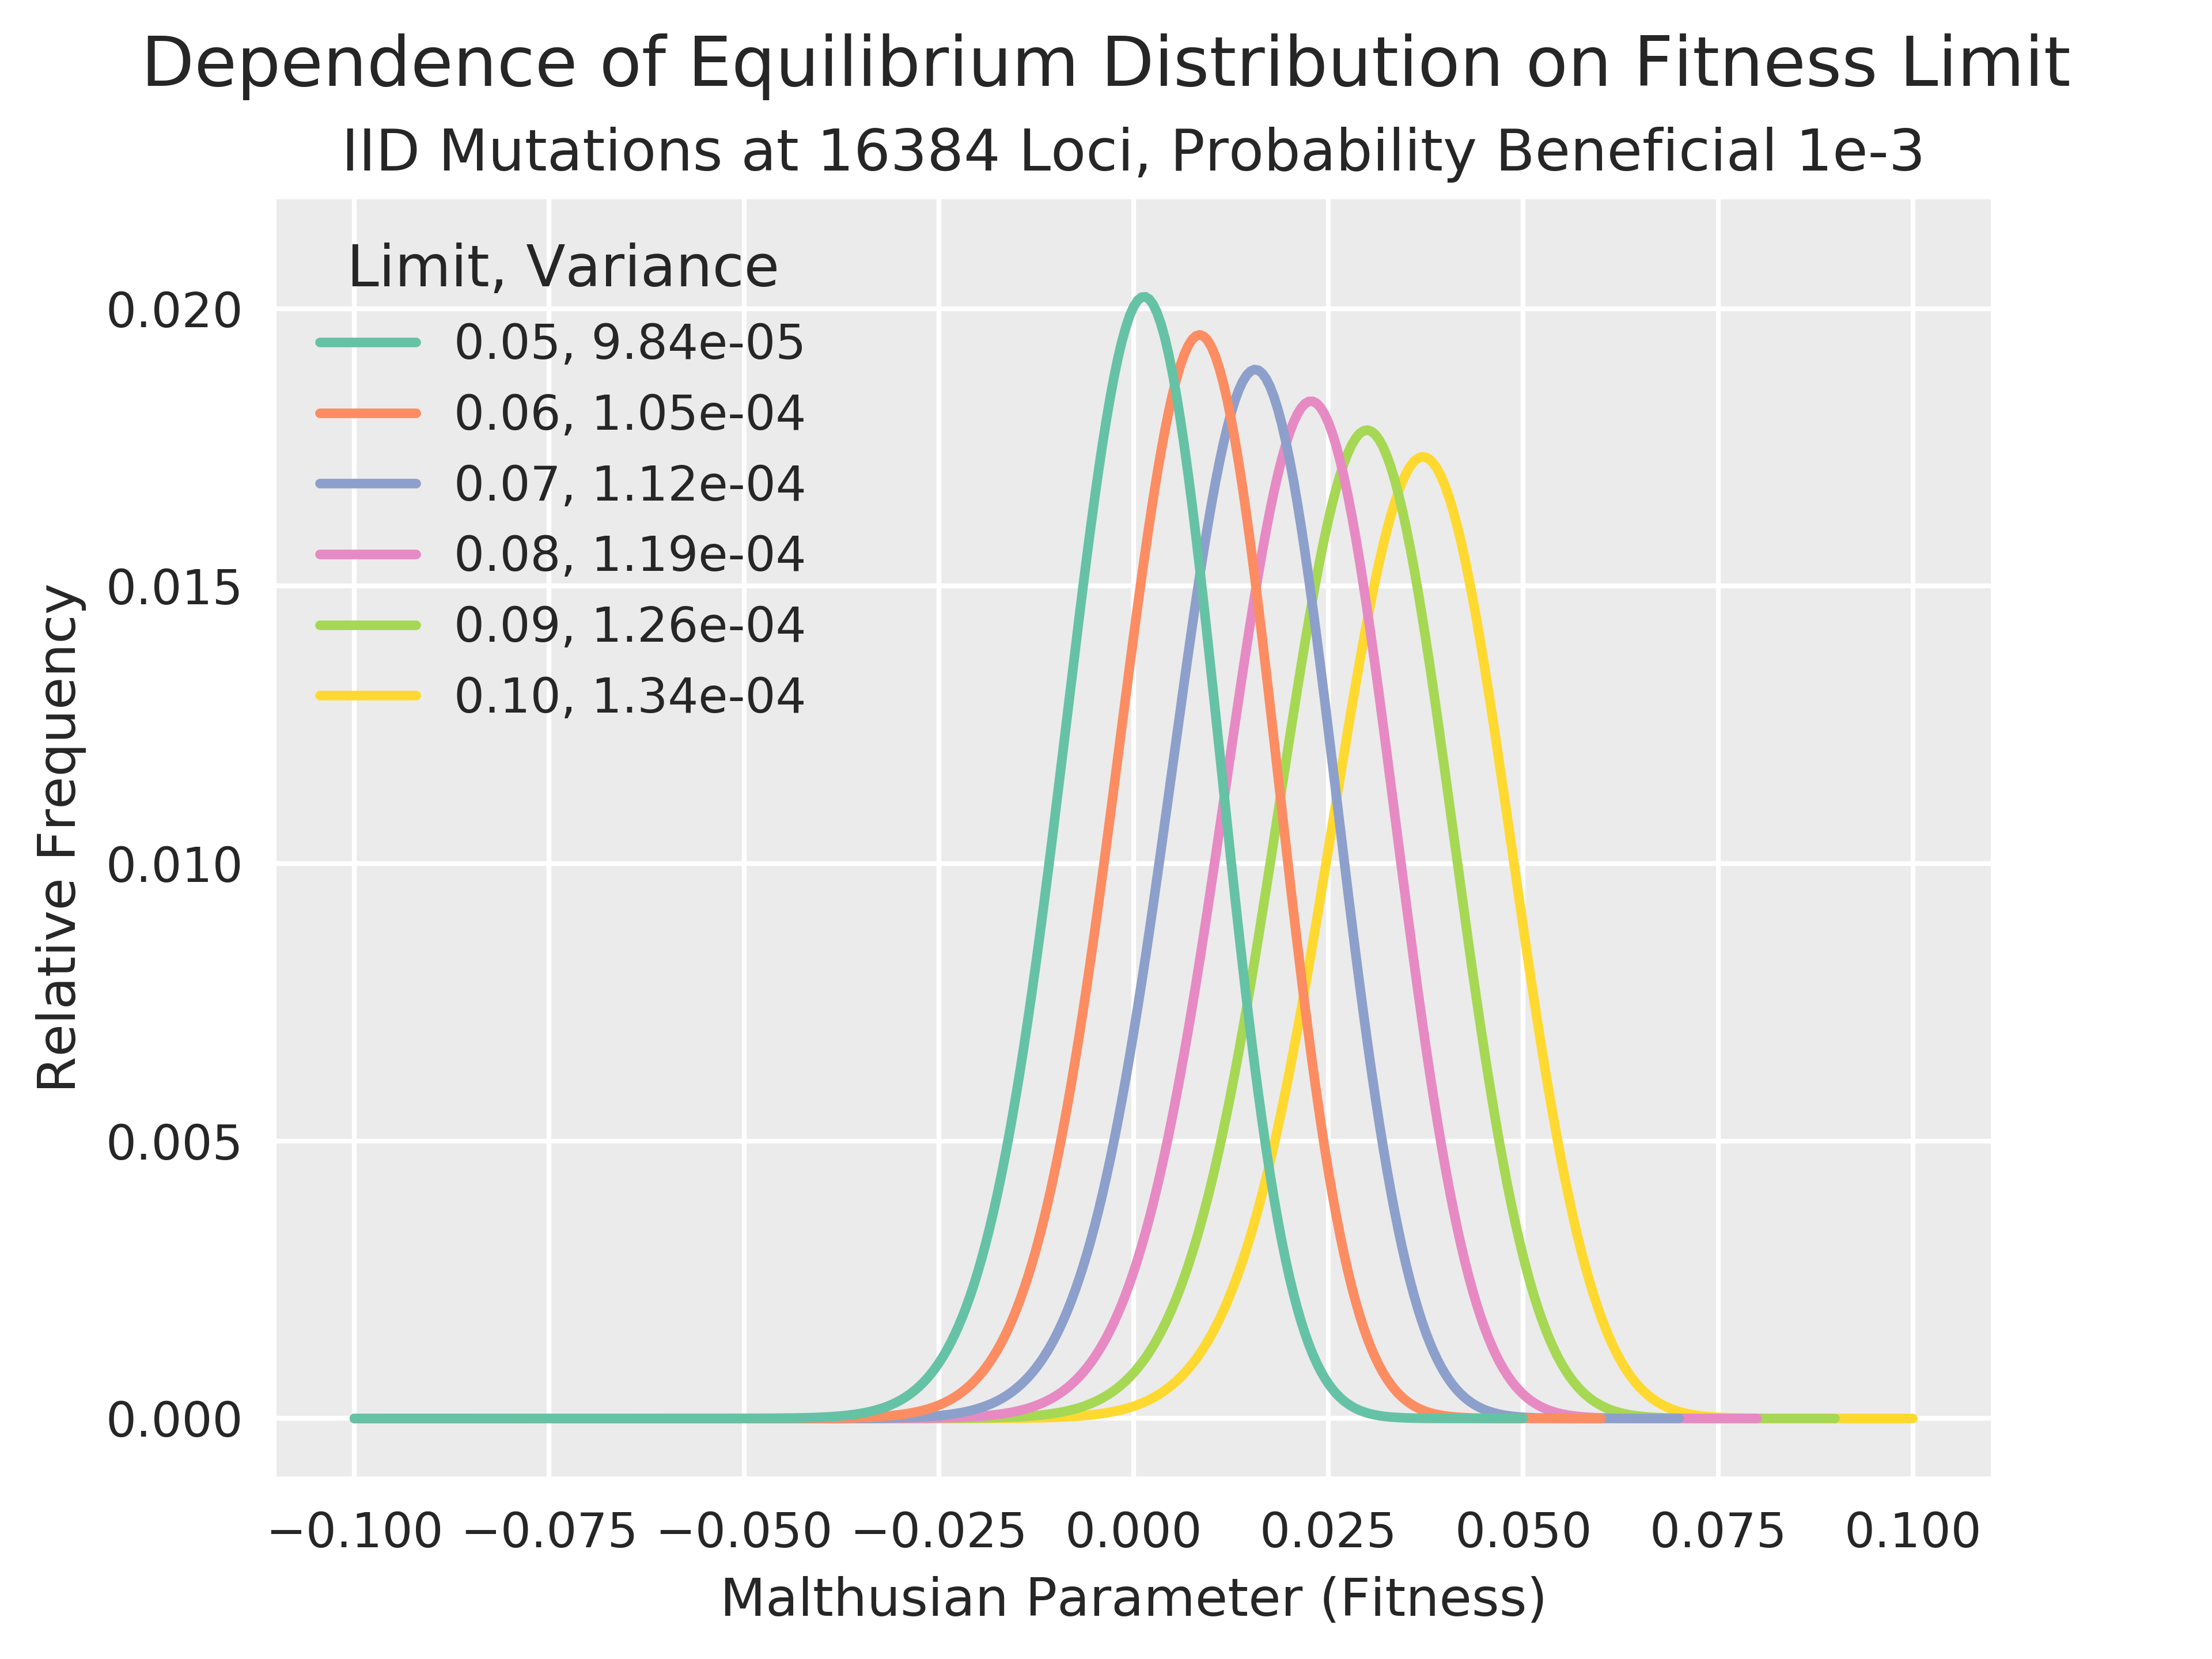

In [7]:
def plot_equilibria(n_loci, equilibria, upper_limits, factors, ylim=None):
    fig, ax = plt.subplots()
    fig.suptitle('Dependence of Equilibrium Distribution on Fitness Limit')
    if n_loci is 1:
        title = 'Mutation at 1 Locus, Probability Beneficial '
    else:
        title = 'IID Mutations at {0} Loci, Probability Beneficial '
        title = title.format(n_loci)
    title = title + fraction_of_mutations_that_are_beneficial
    ax.set_title(title)
    ax.set_ylabel('Relative Frequency')
    ax.set_xlabel('Malthusian Parameter (Fitness)')
    z = 100
    for eq, limit, f in zip(equilibria, upper_limits, factors):
        _, variance = mean_and_variance(f.growth, eq)
        label = '{0}, {1:4.2e}'.format(limit, variance)
        ax.plot(f.growth, eq, label=label, zorder=z)
        z -= 1
    ax.legend(title='Limit, Variance', loc='upper left')
    ax.set_ylim(ylim)
    filename = ax.get_title() + '.png'
    fig.savefig(filename, format='png', dpi=600)
    display(Image(filename=filename))
    return fig, ax

sns.set_palette(sns.color_palette("Set2", len(upper_limits)))
plt.interactive(False)
fig, ax = plot_equilibria(1, eq_one_locus, upper_limits, factors)
ylim = ax.get_ylim()
fig, ax = plot_equilibria(2**14, eq_many_loci, upper_limits, factors, ylim)

Note that the right tail of each equilibrium distribution is plotted only to the upper limit on fitness. All left tails extend to -0.1, where the birth rate is 0.